In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
images = [os.path.join('data/images',f) for f in os.listdir('data/images') if f.endswith(('.jpg'))]

In [ ]:
len(images)

In [ ]:
imgs = [plt.imread(i) for i in images]

In [ ]:
imgs = [i for i in imgs if i.shape[-1]==3]
shapes = ([np.array(img.shape) for img in (imgs)])

In [ ]:
len(imgs)

In [ ]:
shapes

In [ ]:
np.argmin(W)

In [ ]:
plt.imshow(imgs[5929])

In [ ]:

d

In [ ]:
d.resize((224,224),resample=Image.LANCZOS)

In [ ]:
from PIL.ImageOps import solarize,posterize,autocontrast,equalize

In [ ]:
import random
e = 


In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image
from PIL.ImageOps import autocontrast, posterize
from PIL.ImageTransform import AffineTransform

# pick random image
d = Image.fromarray(random.choice(imgs))

from PIL import ImageEnhance

def mild_color(img):
    img = ImageEnhance.Brightness(img).enhance(random.uniform(0.9, 1.1))
    img = ImageEnhance.Contrast(img).enhance(random.uniform(0.9, 1.1))
    img = ImageEnhance.Color(img).enhance(random.uniform(0.9, 1.1))
    return img

def slight_affine_coeffs(eps=0.02, translate=2):
    return (
        1 + random.uniform(-eps, eps),  # a
        random.uniform(-eps, eps),      # b
        random.uniform(-translate, translate),  # c
        random.uniform(-eps, eps),      # d
        1 + random.uniform(-eps, eps),  # e
        random.uniform(-translate, translate)   # f
    )

def augment(img):
    coeff = slight_affine_coeffs()
    t = AffineTransform(coeff)
    
    e = t.transform(img.size, img)
    e = e.resize((224, 224), Image.LANCZOS)
    
    e = mild_color(e)  # replace harsh ops
    
    return e

# generate 5 augmented images
augmented = [augment(d) for _ in range(5)]

# plot
plt.figure(figsize=(12, 4))

# original
plt.subplot(1, 6, 1)
plt.imshow(d)
plt.title("Original")
plt.axis("off")

# augmented
for i, img in enumerate(augmented):
    plt.subplot(1, 6, i + 2)
    plt.imshow(img)
    plt.title(f"Aug {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from data.pets_dataset import OxfordIIITPetDataset_localize



In [ ]:
d

In [ ]:
import os
import xml.etree.ElementTree as ET

with open('data/annotations/trainval.txt') as f:
    content = f.read().split('\n')
# split the train val from the list above and the dataset takes this list as input 


# store (image_path, class_id, seg_path, species, breed_id)
data = []

for c in content:
    name,c_id,sp,brd = c.split(' ')
    class_id = int(c_id)
    species  = int(sp)
    breed_id = int(brd)

    img_path = os.path.join('images',name+'.jpg')
    seg_path = os.path.join('annotations/trimaps',name+'.png')

    data.append((img_path, class_id, seg_path, species, breed_id))

In [ ]:
ET.parse("data/annotations/xmls/Abyssinian_1.xml")

In [ ]:
not_exist = []
with open('data/annotations/train.txt') as f:
    content_test = f.read().split('\n')
for c in content_test:

    name,c_id,sp,brd = c.split(' ')

    if not os.path.exists(os.path.join('data/annotations/xmls', name+'.xml')):
        not_exist.append(name)


In [ ]:
len(not_exist)

In [1]:
from data.pets_dataset import *


In [2]:
with open('data/annotations/trainval.txt') as f:
    contents = f.read().split('\n')

np.random.shuffle(contents)
split_idx = int(len(contents)*0.8)
train_data = contents[:split_idx]
val_data = contents[split_idx:]

In [3]:
train_dataset = OxfordIIITPetDataset_localize(train_data, transform=Image_transform)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def visualize_dataset(dataset, num_samples=9, cols=3):
    """
    Args:
        dataset    : returns (image, bbox) where bbox = (xc, yc, w, h)
        num_samples: how many to show
        cols       : grid columns
    """
    rows = (num_samples + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    axes = axes.flatten()

    for i in range(num_samples):
        sample = dataset[i]
        image, bbox = sample[0], sample[1]

        ax = axes[i]

        img_show = np.transpose(image, (1, 2, 0))
        img_show = np.clip(img_show, 0, 1)  
        ax.imshow(img_show)

        xc, yc, w, h = bbox


        x0 = xc - w / 2
        y0 = yc - h / 2

        rect = patches.Rectangle(
            (x0, y0), w, h,
            linewidth=2,
            edgecolor='lime',
            facecolor='none'
        )
        ax.add_patch(rect)
        ax.set_title(f'Sample {i}', fontsize=10)
        ax.axis('off')

    for j in range(num_samples, len(axes)):
        axes[j].axis('off')

    plt.suptitle('Dataset Visualization', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

visualize_dataset(train_dataset, num_samples=10, cols=3)

In [4]:
train_dataset = OxfordIIITPetDataset_Segmentation(train_data, Image_transform)

In [5]:
len(train_dataset)

2944

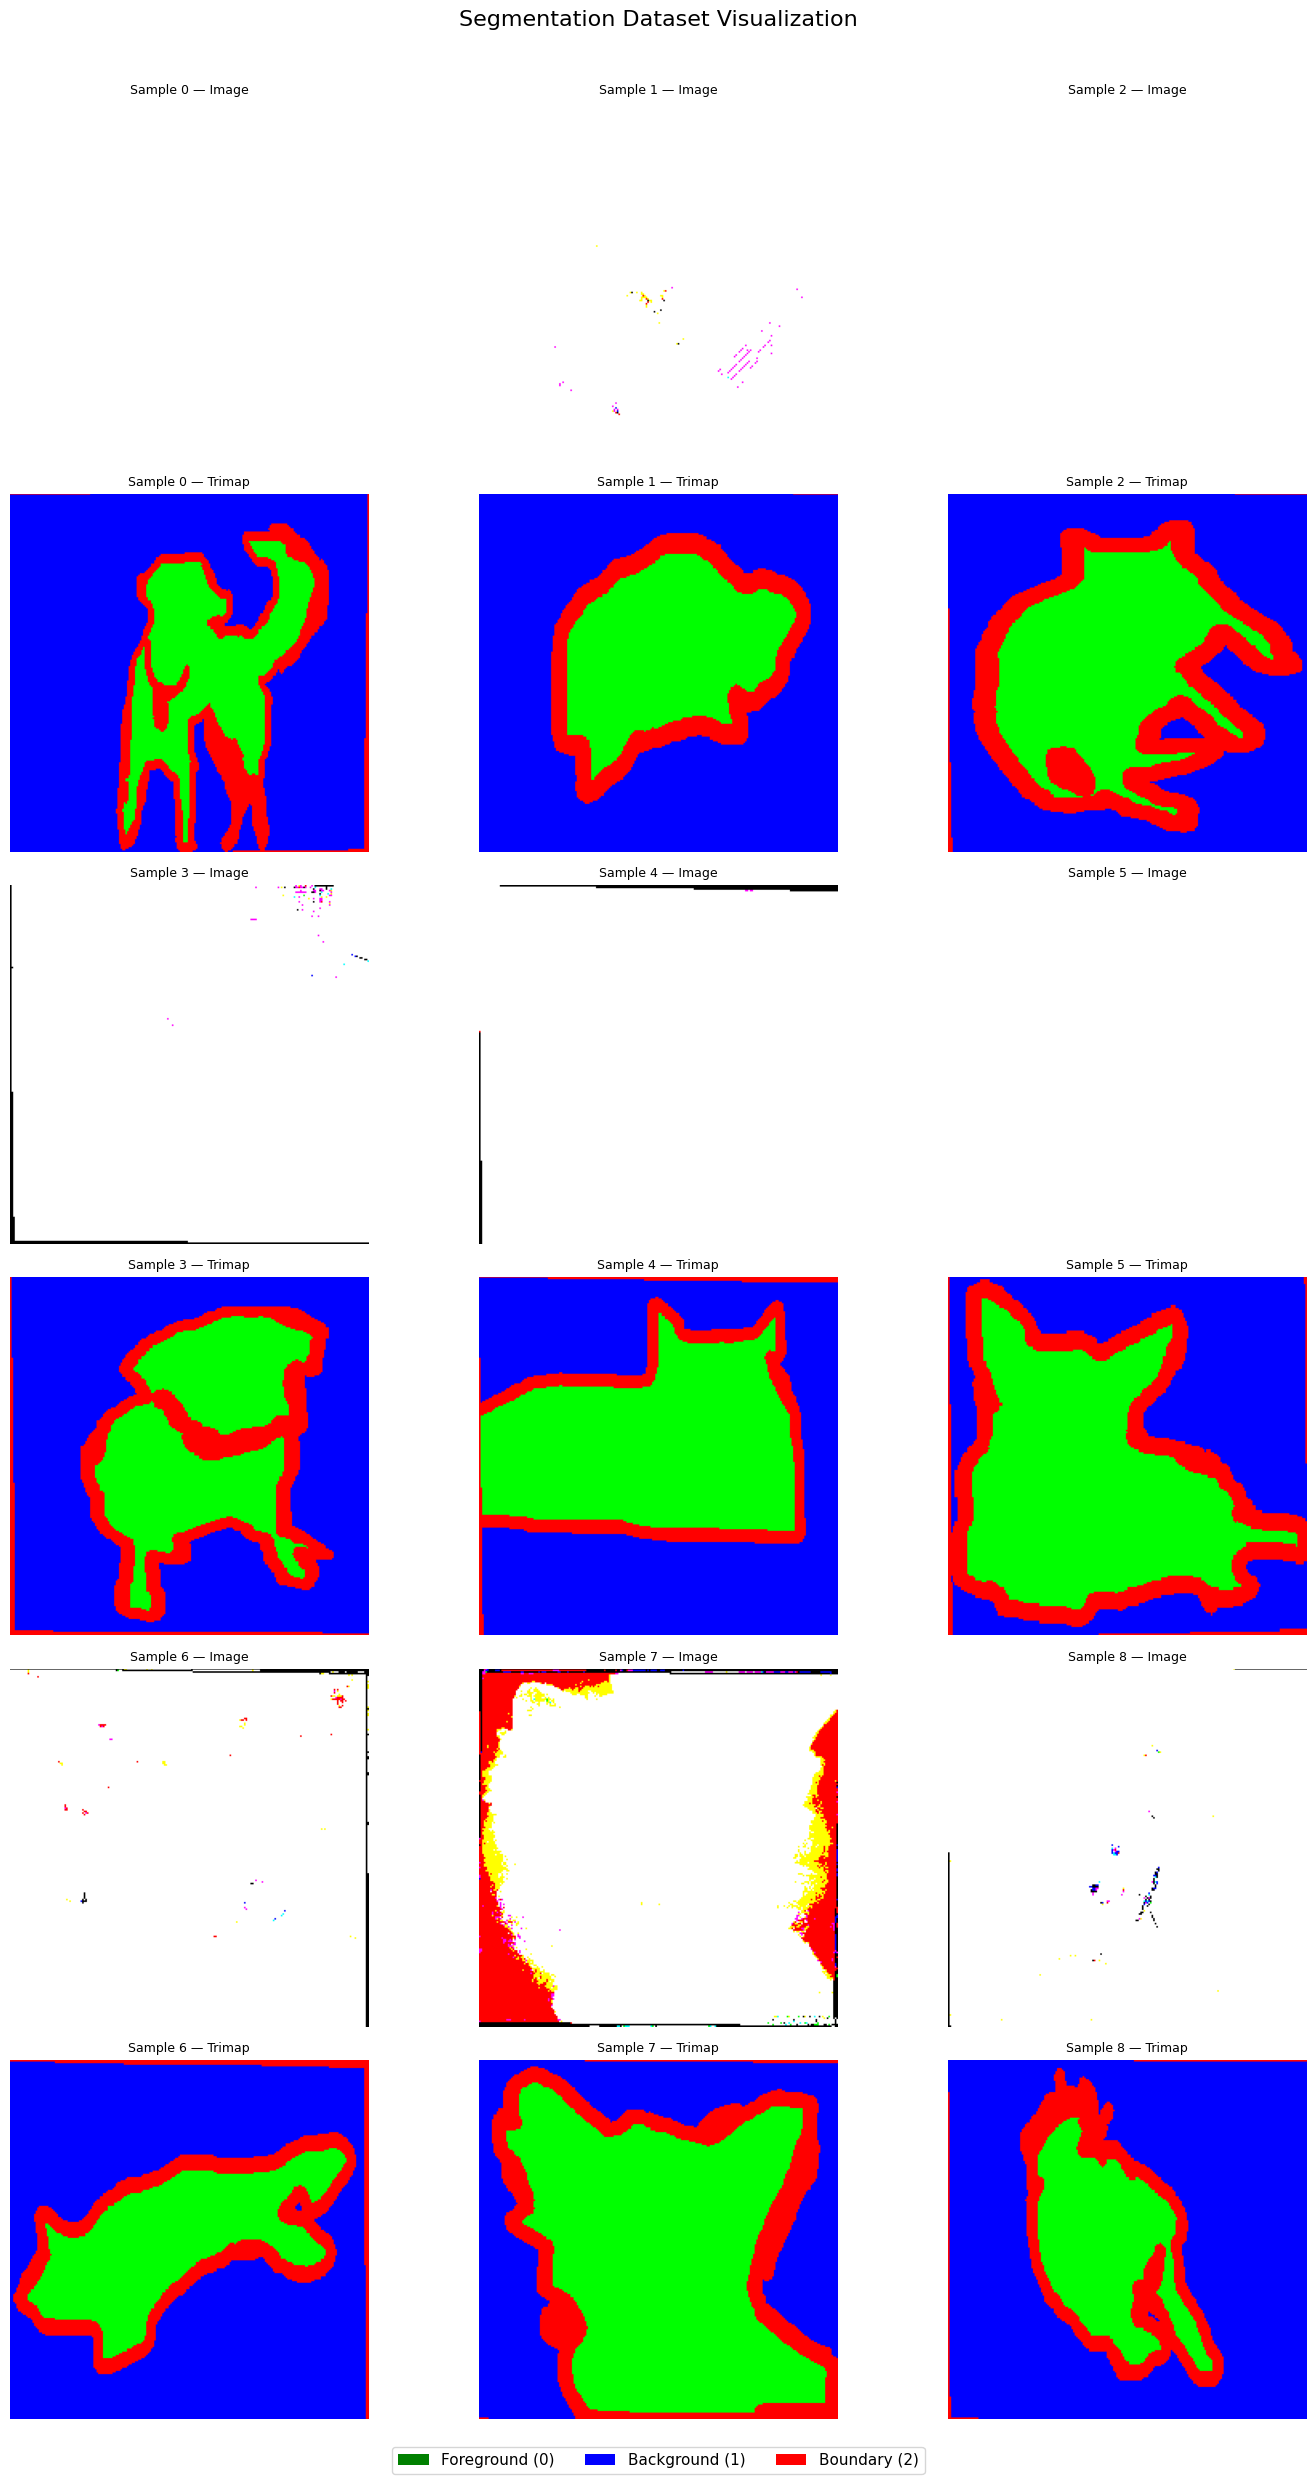

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def visualize_segmentation_dataset(dataset, num_samples=9, cols=3):
    """
    Args:
        dataset: returns (image, trimap) where
                 image  = tensor [3, 224, 224] normalized
                 trimap = tensor [224, 224] with values 0/1/2
    """
    # Color map for trimap classes
    # 0 = foreground, 1 = background, 2 = boundary
    color_map = np.array([
        [0,   255, 0  ],   # 0: foreground  → green
        [0,   0,   255],   # 1: background  → blue
        [255, 0,   0  ],   # 2: boundary    → red
    ], dtype=np.uint8)

    rows = (num_samples + cols - 1) // cols
    fig, axes = plt.subplots(rows * 2, cols, figsize=(5 * cols, 4 * rows * 2))

    for i in range(num_samples):
        image, trimap = dataset[i]

        # Denormalize image
        img_show = np.transpose(image.numpy(), (1, 2, 0))  # [H, W, 3]
        img_show = img_show 
        img_show = np.clip(img_show, 0, 1)

        # Convert trimap to RGB color map
        trimap_np = trimap.numpy().astype(np.int32)        # [H, W]
        trimap_rgb = color_map[trimap_np]                  # [H, W, 3]

        row = (i // cols) * 2
        col =  i  % cols

        # Top row: image
        axes[row][col].imshow(img_show)
        axes[row][col].set_title(f'Sample {i} — Image', fontsize=9)
        axes[row][col].axis('off')

        # Bottom row: trimap mask
        axes[row + 1][col].imshow(trimap_rgb)
        axes[row + 1][col].set_title(f'Sample {i} — Trimap', fontsize=9)
        axes[row + 1][col].axis('off')

    # Hide unused axes
    for i in range(num_samples, rows * cols):
        row = (i // cols) * 2
        col =  i  % cols
        axes[row][col].axis('off')
        axes[row + 1][col].axis('off')

    # Legend
    legend_elements = [
        patches.Patch(facecolor='green', label='Foreground (0)'),
        patches.Patch(facecolor='blue',  label='Background (1)'),
        patches.Patch(facecolor='red',   label='Boundary (2)'),
    ]
    fig.legend(handles=legend_elements, loc='lower center',
               ncol=3, fontsize=11, bbox_to_anchor=(0.5, -0.02))

    plt.suptitle('Segmentation Dataset Visualization', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.show()

visualize_segmentation_dataset(train_dataset, num_samples=9, cols=3)

In [ ]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_dataset,32,True)

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
for img,class_id in train_dataloader:
    a = img
    b = class_id
    break

In [ ]:
b.shape

In [ ]:
import random
from PIL.ImageTransform import AffineTransform

In [ ]:
eps = 0.02 ; translate = 2
affine_coeffs = (
    1 + random.uniform(-eps, eps),  # a
    random.uniform(-eps, eps),      # b
    random.uniform(-translate, translate),  # c
    random.uniform(-eps, eps),      # d
    1 + random.uniform(-eps, eps),  # e
    random.uniform(-translate, translate)   # f
)


t = AffineTransform(affine_coeffs)

In [ ]:
t.data

In [ ]:
from losses.iou_loss import IoULoss

Loss = IoULoss()

In [ ]:
import torch

pred_box = torch.rand((32,4))*224


In [ ]:
Loss.forward(pred_box, b)